
# Snoring vs Non‑Snoring — **Non‑Deep Learning** (Random Forest) ✅

This notebook mirrors your original pipeline’s **data augmentation** (same functions, same SNR 5–20 dB), but **skips YAMNet/deep learning** so you can measure the impact.  
We extract classical features with `librosa` and train a `RandomForestClassifier`.

**Unchanged (from your project):**
- Dataset download from Kaggle (snore + ESC‑50 noise)
- `mix_audio_with_noise` and `load_with_optional_noise` augmentation with random SNR in **[5, 20] dB**
- Train/test split and separate **clean vs. noisy** test evaluation

**Changed:**
- No TensorFlow Hub / **YAMNet** (skipped)
- Classical audio features (MFCCs + deltas, log‑mel stats, spectral stats, ZCR, RMS)
- Classifier: **RandomForestClassifier** (scikit‑learn)


In [ ]:

# === Install required packages ===
!pip -q install librosa==0.10.2.post1 soundfile==0.12.1 noisereduce==3.0.2 tqdm==4.66.5 scikit-learn==1.5.1 matplotlib==3.9.2 pandas==2.2.2 kaggle==1.6.17


In [ ]:

# === Mount Google Drive & set up Kaggle ===
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
print("👉 Please upload your kaggle.json (Kaggle: Account > Create API Token)")
uploaded = files.upload()  # Upload kaggle.json when prompted

import os, shutil, json
assert 'kaggle.json' in uploaded, "kaggle.json is required to access Kaggle datasets."
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("kaggle.json installed ✅")


Mounted at /content/drive
👉 Please upload your kaggle.json (Kaggle: Account > Create API Token)


Saving kaggle.json to kaggle.json
kaggle.json installed ✅


In [ ]:

# === Create folders & download datasets (same as project file) ===
!mkdir -p "/content/drive/MyDrive/snore_data"
!mkdir -p "/content/drive/MyDrive/noise_data"

# Snoring dataset
!kaggle datasets download tareqkhanemu/snoring -p "/content/drive/MyDrive/snore_data" --unzip

# ESC-50 (concatenated class WAVs) noise
!kaggle datasets download mmoreaux/environmental-sound-classification-50 -p "/content/drive/MyDrive/noise_data" --unzip


Dataset URL: https://www.kaggle.com/datasets/tareqkhanemu/snoring
License(s): unknown
snoring.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
License(s): CC-BY-NC-SA-4.0
environmental-sound-classification-50.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:

# === Paths & sanity check ===
import os

SNORE_PATH      = "/content/drive/MyDrive/snore_data/Snoring Dataset/1"   # snore
NON_SNORE_PATH  = "/content/drive/MyDrive/snore_data/Snoring Dataset/0"   # non-snore
NOISE_PATH      = "/content/drive/MyDrive/noise_data/audio/audio"         # ESC-50 concatenated WAVs

snore_cnt = len([f for f in os.listdir(SNORE_PATH) if f.lower().endswith('.wav')])
nons_cnt  = len([f for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith('.wav')])
noise_cnt = len([f for f in os.listdir(NOISE_PATH) if f.lower().endswith('.wav')])

print("Snore files:", snore_cnt)
print("Non-snore files:", nons_cnt)
print("Noise wavs:", noise_cnt)
assert snore_cnt > 0 and nons_cnt > 0 and noise_cnt > 0, "Check dataset paths — expected .wav files."


Snore files: 500
Non-snore files: 500
Noise wavs: 2000


In [ ]:

# === Augmentation utilities (SAME as your project code) ===
import numpy as np
import librosa, random, os

# Collect available noise wavs
noise_files = [os.path.join(NOISE_PATH, f) for f in os.listdir(NOISE_PATH) if f.lower().endswith(".wav")]
assert len(noise_files) > 0, "No noise wavs found — check NOISE_PATH."

def mix_audio_with_noise(audio, noise, snr_db=10):
    """Add noise to audio at target SNR (dB)."""
    if len(noise) < len(audio):
        reps = int(np.ceil(len(audio)/len(noise)))
        noise = np.tile(noise, reps)
    noise = noise[:len(audio)]

    eps = 1e-9
    rms_s = np.sqrt(np.mean(audio**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return audio + k*noise

def load_with_optional_noise(file_path, add_noise=False, sr=16000, target_sec=3.0):
    """Load mono audio, pad/trim to target length, optionally add random noise at random SNR."""
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_len = int(sr*target_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    if add_noise and noise_files:
        n, _ = librosa.load(random.choice(noise_files), sr=sr, mono=True)
        snr = random.uniform(5, 20)  # SAME RANGE
        y = mix_audio_with_noise(y, n, snr_db=snr)
    return y.astype(np.float32)


In [ ]:

# === Classical feature extraction (no deep learning) ===
import numpy as np
import librosa

def extract_features_waveform(y, sr=16000):
    """
    Extract non–deep learning features:
      - MFCC(40) + delta + delta2 -> mean & std over time
      - Log-mel spectrogram (64 bands) -> mean & std
      - Spectral stats: centroid, bandwidth, rolloff, contrast, flatness
      - ZCR, RMS -> mean & std
    Returns a 1D numpy vector.
    """
    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_d1 = librosa.feature.delta(mfcc)
    mfcc_d2 = librosa.feature.delta(mfcc, order=2)
    mfcc_stats = np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        mfcc_d1.mean(axis=1), mfcc_d1.std(axis=1),
        mfcc_d2.mean(axis=1), mfcc_d2.std(axis=1),
    ], axis=0)

    # Log-mel
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    logmel = librosa.power_to_db(S + 1e-9)
    logmel_stats = np.concatenate([logmel.mean(axis=1), logmel.std(axis=1)], axis=0)

    # Spectral features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(S=librosa.stft(y, n_fft=1024), sr=sr)
    flatness = librosa.feature.spectral_flatness(y=y)

    spec_stats = np.concatenate([
        centroid.mean(axis=1), centroid.std(axis=1),
        bandwidth.mean(axis=1), bandwidth.std(axis=1),
        rolloff.mean(axis=1), rolloff.std(axis=1),
        contrast.mean(axis=1), contrast.std(axis=1),
        flatness.mean(axis=1), flatness.std(axis=1),
    ], axis=0)

    # ZCR & RMS
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)
    zcr_rms_stats = np.array([zcr.mean(), zcr.std(), rms.mean(), rms.std()])

    feats = np.concatenate([mfcc_stats, logmel_stats, spec_stats, zcr_rms_stats], axis=0)
    return feats.astype(np.float32)


In [ ]:

# === Prepare train/test splits (same as project) ===
from sklearn.model_selection import train_test_split
import numpy as np
import os

snore_files = [os.path.join(SNORE_PATH, f) for f in os.listdir(SNORE_PATH) if f.lower().endswith('.wav')]
non_files   = [os.path.join(NON_SNORE_PATH, f) for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith('.wav')]

X_paths = snore_files + non_files
y_all   = np.array([1]*len(snore_files) + [0]*len(non_files))

X_tr_paths, X_te_paths, y_tr, y_te = train_test_split(
    X_paths, y_all, test_size=0.2, random_state=42, stratify=y_all
)

len(snore_files), len(non_files), len(X_tr_paths), len(X_te_paths)


(500, 500, 800, 200)

In [ ]:

# === Feature extraction with augmentation for TRAIN only (unchanged logic) ===
from tqdm import tqdm
import numpy as np

def features_from_paths(paths, add_noise=False, sr=16000, target_sec=3.0):
    feats = []
    for p in tqdm(paths, desc=f"Extracting (add_noise={add_noise})"):
        y = load_with_optional_noise(p, add_noise=add_noise, sr=sr, target_sec=target_sec)
        feats.append(extract_features_waveform(y, sr=sr))
    return np.stack(feats)

X_tr = features_from_paths(X_tr_paths, add_noise=True)   # AUGMENT HERE (same)
X_te = features_from_paths(X_te_paths, add_noise=False)  # CLEAN TEST
X_tr.shape, X_te.shape


Extracting (add_noise=True):   0%|          | 0/800 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/librosa/feature/spectral.py:520: ComplexWarning: Casting complex values to real discards the imaginary part
  valley[..., k, :] = np.mean(sortedr[..., :idx, :], axis=-2)
/usr/local/lib/python3.11/dist-packages/librosa/feature/spectral.py:521: ComplexWarning: Casting complex values to real discards the imaginary part
  peak[..., k, :] = np.mean(sortedr[..., -idx:, :], axis=-2)
Extracting (add_noise=False): 100%|██████████| 200/200 [00:52<00:00,  3.79it/s]


((800, 394), (200, 394))

In [ ]:

# === Train RandomForest (no deep learning) ===
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf.fit(X_tr, y_tr)


RandomForestClassifier(class_weight='balanced_subsample', n_estimators=500,
                       n_jobs=-1, random_state=42)

=== Clean Test ===
              precision    recall  f1-score   support

           0     0.7071    0.9900    0.8250       100
           1     0.9833    0.5900    0.7375       100

    accuracy                         0.7900       200
   macro avg     0.8452    0.7900    0.7812       200
weighted avg     0.8452    0.7900    0.7812       200

ROC-AUC: 0.9541


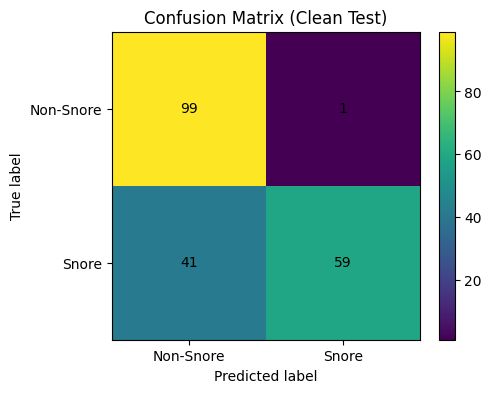

In [ ]:

# === Evaluate on CLEAN test ===
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

probs = rf.predict_proba(X_te)[:,1]
preds = (probs >= 0.5).astype(int)

print("=== Clean Test ===")
print(classification_report(y_te, preds, digits=4))
try:
    print("ROC-AUC:", roc_auc_score(y_te, probs))
except Exception as e:
    print("ROC-AUC could not be computed:", e)

cm = confusion_matrix(y_te, preds)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix (Clean Test)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Non-Snore','Snore'])
plt.yticks(tick_marks, ['Non-Snore','Snore'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.show()


Extracting (add_noise=True):   0%|          | 0/200 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/librosa/feature/spectral.py:520: ComplexWarning: Casting complex values to real discards the imaginary part
  valley[..., k, :] = np.mean(sortedr[..., :idx, :], axis=-2)
/usr/local/lib/python3.11/dist-packages/librosa/feature/spectral.py:521: ComplexWarning: Casting complex values to real discards the imaginary part
  peak[..., k, :] = np.mean(sortedr[..., -idx:, :], axis=-2)
Extracting (add_noise=True): 100%|██████████| 200/200 [01:01<00:00,  3.24it/s]


=== Noisy Test ===
              precision    recall  f1-score   support

           0     0.7477    0.8000    0.7729       100
           1     0.7849    0.7300    0.7565       100

    accuracy                         0.7650       200
   macro avg     0.7663    0.7650    0.7647       200
weighted avg     0.7663    0.7650    0.7647       200

ROC-AUC (noisy): 0.85535


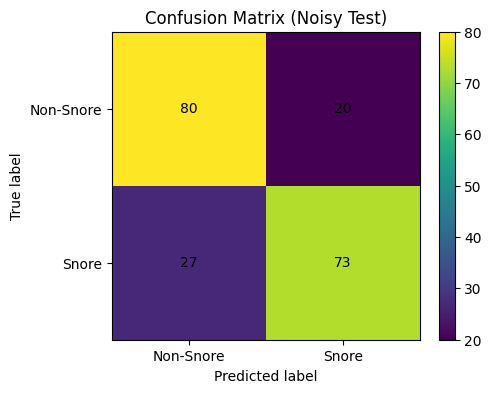

In [ ]:

# === Evaluate on NOISY test (simulate deployment noise) ===
X_te_noisy = features_from_paths(X_te_paths, add_noise=True)  # noisy inference
probs_n = rf.predict_proba(X_te_noisy)[:,1]
preds_n = (probs_n >= 0.5).astype(int)

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
print("=== Noisy Test ===")
print(classification_report(y_te, preds_n, digits=4))
try:
    print("ROC-AUC (noisy):", roc_auc_score(y_te, probs_n))
except Exception as e:
    print("ROC-AUC (noisy) could not be computed:", e)

cm_n = confusion_matrix(y_te, preds_n)
import matplotlib.pyplot as plt, numpy as np
plt.figure(figsize=(5,4))
plt.imshow(cm_n, interpolation='nearest')
plt.title('Confusion Matrix (Noisy Test)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Non-Snore','Snore'])
plt.yticks(tick_marks, ['Non-Snore','Snore'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_n[i, j], ha='center', va='center')
plt.show()


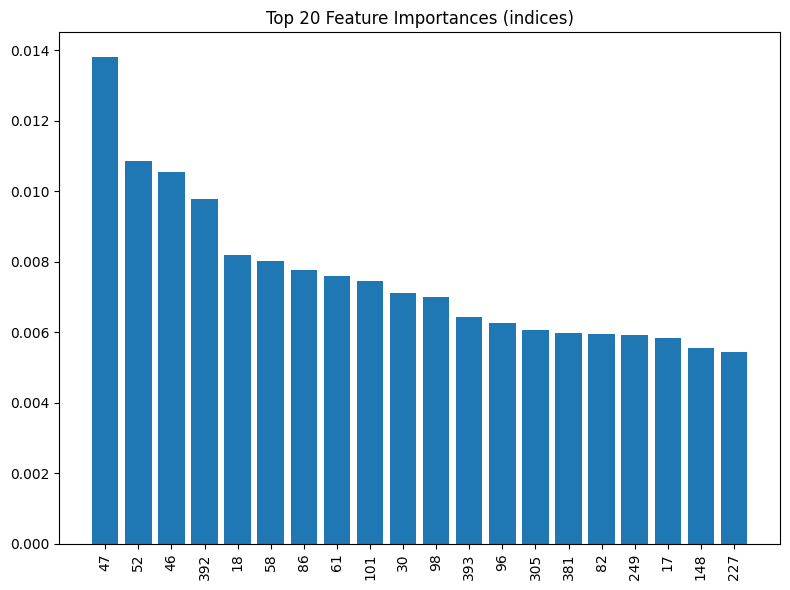

Top 20 feature indices and importances:
 1. idx= 47  imp=0.01381
 2. idx= 52  imp=0.01087
 3. idx= 46  imp=0.01055
 4. idx=392  imp=0.00978
 5. idx= 18  imp=0.00819
 6. idx= 58  imp=0.00802
 7. idx= 86  imp=0.00776
 8. idx= 61  imp=0.00760
 9. idx=101  imp=0.00746
10. idx= 30  imp=0.00712
11. idx= 98  imp=0.00701
12. idx=393  imp=0.00642
13. idx= 96  imp=0.00625
14. idx=305  imp=0.00607
15. idx=381  imp=0.00597
16. idx= 82  imp=0.00596
17. idx=249  imp=0.00593
18. idx= 17  imp=0.00584
19. idx=148  imp=0.00556
20. idx=227  imp=0.00543


In [ ]:

# === Feature importance (top 20) ===
import numpy as np
import matplotlib.pyplot as plt

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8,6))
plt.bar(range(len(idx)), importances[idx])
plt.xticks(range(len(idx)), idx, rotation=90)
plt.title('Top 20 Feature Importances (indices)')
plt.tight_layout()
plt.show()

print("Top 20 feature indices and importances:")
for rank, i in enumerate(idx, 1):
    print(f"{rank:2d}. idx={i:3d}  imp={importances[i]:.5f}")



## Where the augmentation happens
- **Training augmentation**: `X_tr = features_from_paths(X_tr_paths, add_noise=True)`  
- **Clean test**: `X_te = features_from_paths(X_te_paths, add_noise=False)`  
- **Noisy test**: `X_te_noisy = features_from_paths(X_te_paths, add_noise=True)`  

You can now directly compare these results with your YAMNet model to see the impact of skipping deep learning.
